Vector 1 = (1, 0, 1, 1, 0)
Vector 2 = (1, 0, 1, 0, 1)

Euclidean Distance: 1.41421
Manhattan Distance: 2

Accuracy: 60.0%
Generalization Error: 15%

Precision: 0.80
Recall: 0.67
F1 Score: 0.73

Confusion Matrix:
True Positives (TP): 4
False Positives (FP): 1
True Negatives (TN): 3
False Negatives (FN): 2


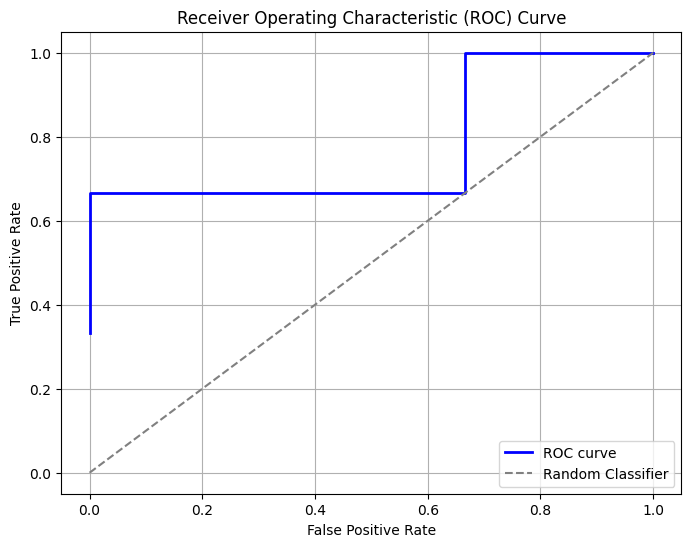

AUC: 0.7778


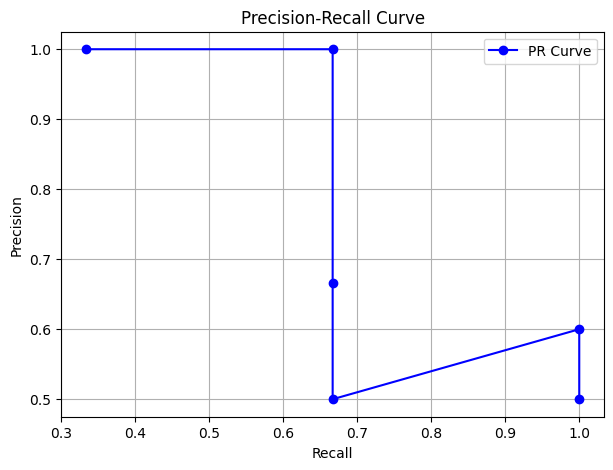

In [5]:
"""
CSC59866
Carlos Rodriguez
Assignment 1: ML
"""

import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Calculates the Euclidean distance between two vectors
def Euclidean(vec1, vec2):
    if len(vec1) != len(vec2):
        raise ValueError("Vectors must be of the same dimension")
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(vec1, vec2)))

# Calculates the Manhattan distance between two vectors
def Manhattan(vec1, vec2):
    if len(vec1) != len(vec2):
        raise ValueError("Vectors must be of the same dimension")
    return (sum(abs(a - b) for a, b, in zip(vec1, vec2)))

# Computes the accuracy and generalization error of two vectors
def AccNGen(actual, predicted, trainingacc, testacc):
    if len(actual) != len(predicted):
        raise ValueError("Vectors must be of the same dimension")
    genError = abs(trainingacc - testacc)
    
    correct = sum(a == b for a, b in zip(actual, predicted))
    accuracy = (correct / len(actual)) * 100
    
    return (accuracy, genError)

# Computes Precision
def Precision(true, pred):
    TP = sum((t == 1) and (p == 1) for t, p in zip(true, pred))
    FP = sum((t == 0) and (p == 1) for t, p in zip(true, pred))
    return TP / (TP + FP) if (TP + FP) != 0 else 0

# Computes Recall
def Recall(true, pred):
    TP = sum((t == 1) and (p == 1) for t, p in zip(true, pred))
    FN = sum((t == 1) and (p == 0) for t, p in zip(true, pred)) 
    return TP / (TP + FN) if (TP + FN) != 0 else 0

# Computes Precision and Recall
def F1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Computes the confusion matrix of two vectors
def ConfusionMatrix(trueVec, predVec):
    TP = sum((true == 1) and (pred == 1) for true, pred in zip(trueVec, predVec)) # True Positive
    TN = sum((true == 0) and (pred == 0) for true, pred in zip(trueVec, predVec)) # True Negative
    FP = sum((true == 0) and (pred == 1) for true, pred in zip(trueVec, predVec)) # False Positive
    FN = sum((true == 1) and (pred == 0) for true, pred in zip(trueVec, predVec)) # False Negative

    return TP, FP, TN, FN

def roc_curve(y_true, y_scores):
    """
    Generate the Receiver Operating Characteristic (ROC) curve.
    
    Parameters:
    - y_true: Array-like, true binary labels (0 or 1)
    - y_scores: Array-like, predicted scores (probabilities or decision values)
    
    Returns:
    - fpr: False Positive Rate
    - tpr: True Positive Rate
    - thresholds: Threshold values at which TPR and FPR are computed
    """
    # Sort the predicted scores and corresponding true labels in descending order
    thresholds = np.sort(np.unique(y_scores))[::-1]  # Sort descending
    fpr = []
    tpr = []
    
    for threshold in thresholds:
        # Predict labels based on the threshold
        y_pred = (y_scores >= threshold).astype(int)
        
        # Calculate TP, FP, TN, FN
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        
        # Calculate TPR and FPR
        tpr.append(tp / (tp + fn) if (tp + fn) != 0 else 0)  # True Positive Rate (Sensitivity)
        fpr.append(fp / (fp + tn) if (fp + tn) != 0 else 0)  # False Positive Rate (1 - Specificity)

    return np.array(fpr), np.array(tpr), thresholds

def plot_roc_curve(fpr, tpr):
    """
    Plot the ROC curve using the computed FPR and TPR values.
    
    Parameters:
    - fpr: False Positive Rate
    - tpr: True Positive Rate
    """
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label='ROC curve', linewidth=2)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

def auc_roc(fpr, tpr):
    """
    Compute the Area Under the Curve (AUC) for the ROC curve using the trapezoidal rule.
    
    Parameters:
    - fpr: Array-like, False Positive Rate values
    - tpr: Array-like, True Positive Rate values
    
    Returns:
    - auc: The computed AUC value
    """
    return np.trapezoid(y=tpr, x=fpr)  # Trapezoidal rule integration

def precision_recall_curve(y_true, y_scores):
    """
    Compute and plot the Precision-Recall (PR) curve.

    Parameters:
    - y_true: Array-like, true binary labels (0 or 1).
    - y_scores: Array-like, predicted scores (continuous values).

    Returns:
    - precision: List of precision values.
    - recall: List of recall values.
    - thresholds: List of decision thresholds.
    """
    # Sort by predicted scores in descending order
    sorted_indices = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[sorted_indices]
    
    # Initialize variables
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = np.sum(y_true)  # False Negatives initially (all positives missed)
    tn = len(y_true) - fn  # True Negatives

    precision = []
    recall = []
    thresholds = []

    for i in range(len(y_true)):
        if y_true_sorted[i] == 1:
            tp += 1  # Correctly classified positive
            fn -= 1  # One less false negative
        else:
            fp += 1  # Incorrectly classified negative
            
        # Compute Precision & Recall
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        
        precision.append(prec)
        recall.append(rec)
        thresholds.append(y_scores[sorted_indices[i]])  # Store threshold
    
    # Convert lists to numpy arrays
    precision = np.array(precision)
    recall = np.array(recall)
    
    return precision, recall, thresholds

def plot_precision_recall(y_true, y_scores):
    """
    Compute and plot the Precision-Recall curve.

    Parameters:
    - y_true: Array-like, true labels (0 or 1).
    - y_scores: Array-like, predicted scores (continuous values).
    """
    precision, recall, _ = precision_recall_curve(y_true, y_scores)

    # Plot PR Curve
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, marker='o', linestyle='-', color='b', label="PR Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid()
    plt.show()

#Test Parameters for both functions
A = (1,0,1,1,0)
B = (1,0,1,0,1)

# Example true labels and predicted labels
true = [1, 0, 1, 1, 0, 1, 0, 1, 0, 1]
pred = [1, 0, 1, 0, 0, 1, 0, 1, 1, 0]
acc, gen_error = AccNGen(A, B, 95, 80)

# Example usage:
y_true = np.array([0, 0, 1, 1, 0, 1])  # True labels
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.7, 0.9])  # Predicted scores (probabilities)

# Test Methods for each method
euc = Euclidean(A,B)
manh = Manhattan(A,B)
precision_value = Precision(true, pred)
recall_value = Recall(true, pred)
f1_value = F1_score(precision_value, recall_value)
TruePos, FalsePos, TrueNeg, FalseNeg = ConfusionMatrix(true, pred)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Print the test values
print("Vector 1 =", A)
print("Vector 2 =", B)
print()
print(f"Euclidean Distance: {euc:.5f}")
print(f"Manhattan Distance: {manh}")
print()
print(f"Accuracy: {acc}%")
print(f"Generalization Error: {gen_error}%")
print()
print(f"Precision: {precision_value:.2f}")
print(f"Recall: {recall_value:.2f}")
print(f"F1 Score: {f1_value:.2f}")
print()

# Output the confusion matrix
print(f"Confusion Matrix:")
print(f"True Positives (TP): {TruePos}")
print(f"False Positives (FP): {FalsePos}")
print(f"True Negatives (TN): {TrueNeg}")
print(f"False Negatives (FN): {FalseNeg}")

# Print the plots and the AUC
plot_roc_curve(fpr, tpr)
auc_value = auc_roc(fpr, tpr)
print(f"AUC: {auc_value:.4f}")
plot_precision_recall(y_true, y_scores)

In [7]:
import numpy as np
from scipy.spatial.distance import cdist

class KNN_Classifier:
    
    def __init__(self):
        self.X_train = None
        self.Y_train = None
        self.n_neighbors = None
        self.weights = 'uniform'
    
    def fit(self, X, Y, n_neighbors, weights='uniform', **kwargs):
        """
        Fit the KNN classifier to the training data.
        
        Arguments:
        X : ndarray
            A numpy array with rows representing data samples and columns representing features.
        Y : ndarray
            A 1D numpy array with labels corresponding to each row of the feature matrix X.
        n_neighbors : int
            The number of nearest neighbors.
        weights : string, optional (default='uniform')
            The weight function used in prediction. Possible values are 'uniform' and 'distance'.
        kwargs : dictionary
            Additional arguments for the distance function.
        """
        self.X_train = X
        self.Y_train = Y
        self.n_neighbors = n_neighbors
        self.weights = weights
    
    def predict(self, X):
        """
        Predict the labels for the given input samples.
        
        Arguments:
        X : ndarray
            A numpy array containing samples to be used for prediction.
        
        Returns:
        y_pred : ndarray
            1D array of predictions for each sample in X.
        """
        distances = cdist(X, self.X_train)  # Compute distances between X and X_train
        sorted_indices = np.argsort(distances, axis=1)[:, :self.n_neighbors]  # Get indices of nearest neighbors
        nearest_labels = self.Y_train[sorted_indices]  # Get the labels of the nearest neighbors
        
        if self.weights == 'uniform':
            # Uniform weights: simply return the most common label among the nearest neighbors
            y_pred = np.array([np.bincount(nearest).argmax() for nearest in nearest_labels])
        elif self.weights == 'distance':
            # Distance weights: closer neighbors have more influence
            distances_sorted = np.take_along_axis(distances, sorted_indices, axis=1)[:, :self.n_neighbors]
            inverse_distances = 1 / (distances_sorted + 1e-5)  # Avoid division by zero
            weighted_labels = np.array([np.bincount(nearest, weights=inverse_distances[i]).argmax()
                                        for i, nearest in enumerate(nearest_labels)])
            y_pred = weighted_labels
        
        return y_pred

# Create the classifier
knn = KNN_Classifier()

# Fit the model with training data
X_train = np.array([[1, 2], [2, 3], [3, 4], [5, 5], [6, 7]])
Y_train = np.array([0, 0, 1, 1, 2])
knn.fit(X_train, Y_train, n_neighbors=3, weights='distance')

# Predict on new data
X_test = np.array([[2, 3], [5, 5]])
predictions = knn.predict(X_test)
print(predictions)


[0 1]


In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('winequality-white.csv')
# Convert quality column into binary variable
df['quality'] = df['quality'].apply(lambda x: 1 if x > 5 else 0)

# Define target variable and feature matrix
X = df.drop('quality', axis=1).values  # Features matrix (without the 'quality' column)
y = df['quality'].values  # Target vector
summary_stats = df.describe().transpose()[['mean', 'std', '25%', '50%', '75%']]
print(summary_stats)
df = df.sample(frac=1).reset_index(drop=True)
import seaborn as sns
import matplotlib.pyplot as plt

# Generate pair plot for the features in the dataset
sns.pairplot(df)
plt.show()
# Example: dropping redundant features 'feature1' and 'feature2'
df = df.drop(['feature1', 'feature2'], axis=1)
import numpy as np

def partition(X, y, t):
    # t is the proportion for the test set
    n_samples = X.shape[0]
    n_test = int(n_samples * t)
    indices = np.random.permutation(n_samples)
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

# Example usage: partition with 80% training and 20% testing
X_train, X_test, y_train, y_test = partition(X, y, 0.2)
knn = KNN_Classifier()
knn.fit(X_train, y_train, n_neighbors=5, weights='uniform')

# Predict on the test set
y_pred = knn.predict(X_test)

# Import evaluation metrics
from sklearn.metrics import accuracy_score, f1_score

# Calculate accuracy and F1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
from sklearn.preprocessing import StandardScaler

# Standardize the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)
# Re-fit the KNN model on the scaled data
knn.fit(X_train_scaled, y_train, n_neighbors=5, weights='uniform')

# Predict on the standardized test data
y_pred_scaled = knn.predict(X_test_scaled)

# Calculate accuracy and F1 score
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
f1_scaled = f1_score(y_test, y_pred_scaled)

print(f"Standardized Accuracy: {accuracy_scaled}")
print(f"Standardized F1 Score: {f1_scaled}")
# Run KNN with inverse distance weighting
knn.fit(X_train_scaled, y_train, n_neighbors=5, weights='distance')

# Predict on the scaled test data
y_pred_inv_dist = knn.predict(X_test_scaled)

# Calculate accuracy and F1 score
accuracy_inv_dist = accuracy_score(y_test, y_pred_inv_dist)
f1_inv_dist = f1_score(y_test, y_pred_inv_dist)

print(f"Inverse Distance Weighted Accuracy: {accuracy_inv_dist}")
print(f"Inverse Distance Weighted F1 Score: {f1_inv_dist}")


<class 'KeyError'>: 'quality'